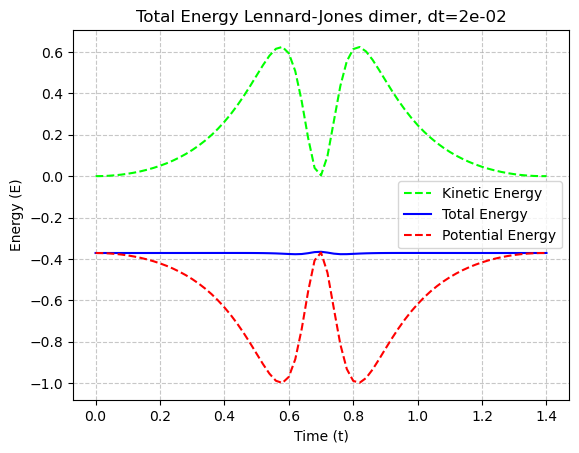

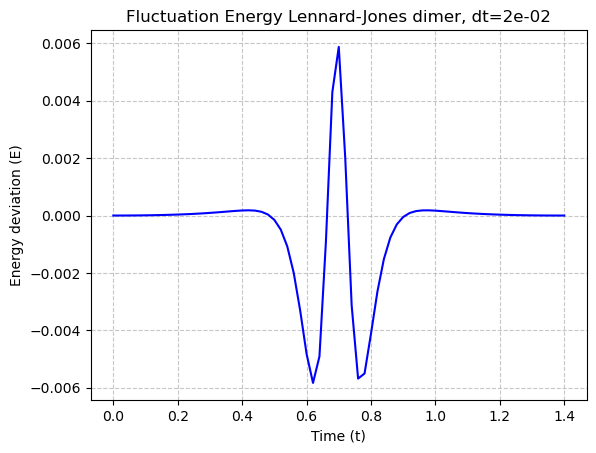

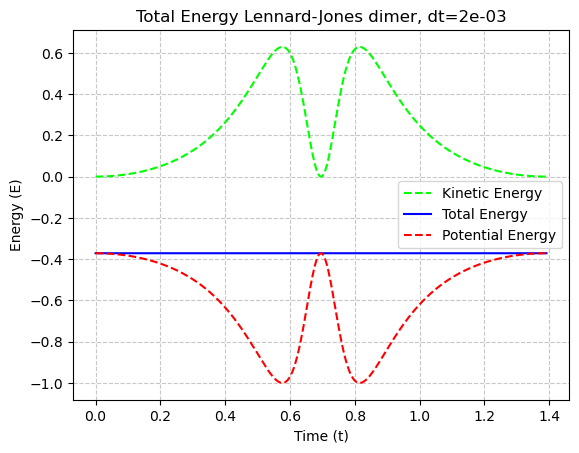

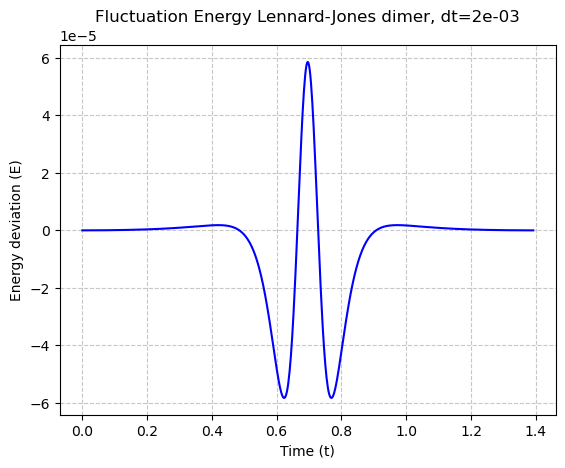

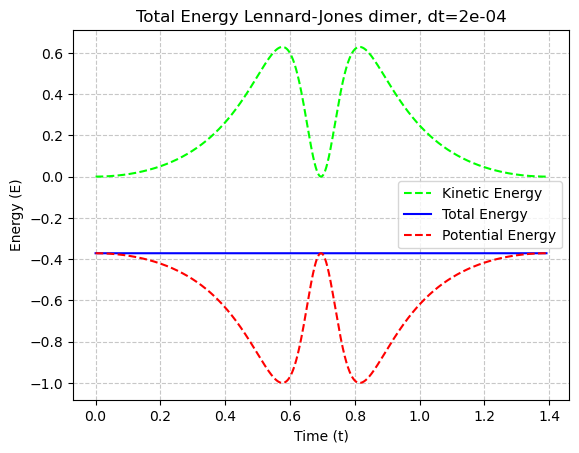

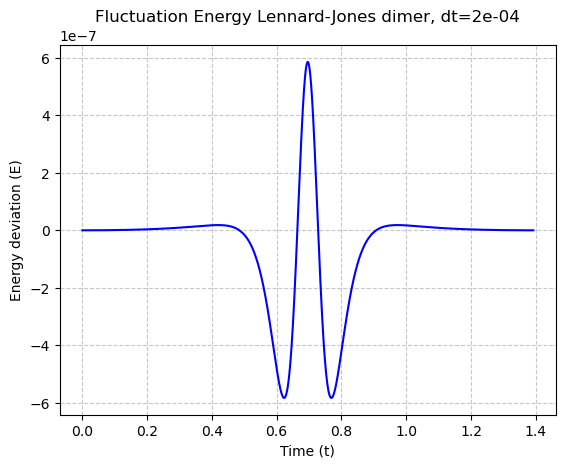

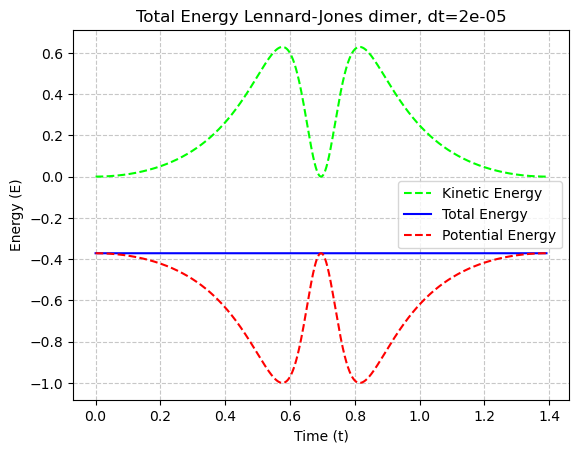

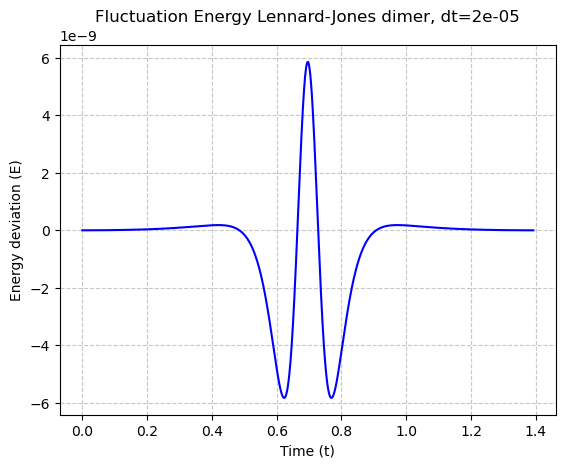

C:\Users\Emma\AppData\Local\Temp\ipykernel_16620\3549157954.py:98: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'ex_1_total_E_dt={timestep:.0e}.png')
C:\Users\Emma\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


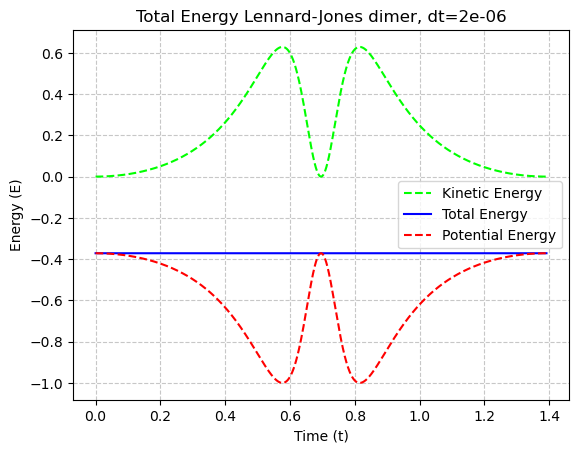

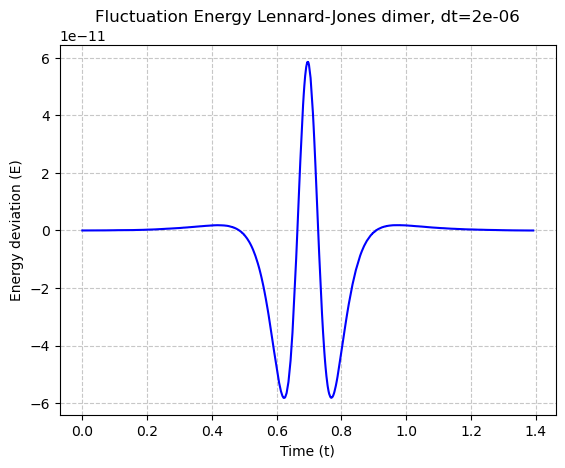

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu May  7 08:58:02 2026

@author: daisy
"""
#ex 1.a
import numpy as np
import matplotlib.pyplot as plt

def normalized_lj_potential(rho):
    rho_inverse_6 = rho ** (-6)
    potential = rho_inverse_6**2 - 2 * rho_inverse_6
    return potential


def normalized_lj_force(rho):
    rho_inverse_6 = rho ** (-6)
    force = 12.0 * (rho_inverse_6**2 - rho_inverse_6) / rho
    return force


def velocity_verlet_integrator(
    initial_position, force_function, dt, max_steps=5_000_000
):
    """
    Integrate one closed orbit using the velocity-Verlet algorithm.

    Starting from (q(0), p(0)) = (q0, 0), the update rule is:

        p_{n+1/2} = p_n       + (dt/2) * F(q_n)
        q_{n+1}   = q_n       + dt     * p_{n+1/2}
        p_{n+1}   = p_{n+1/2} + (dt/2) * F(q_{n+1})

    Integration stops when p changes sign for the second time
    (one full oscillation). Returns None if no orbit is found.
    """

    q, p, t = float(initial_position), 0.0, 0.0
    qs, ps, ts = [q], [p], [t]
    p_prev = 0.0
    zero_crossings = 0

    for _ in range(max_steps):
        # velocity verlet step
        p_half = p + 0.5 * dt * force_function(q)
        q = q + dt * p_half
        p = p_half + 0.5 * dt * force_function(q)
        t += dt

        # accumulate values
        qs.append(q)
        ps.append(p)
        ts.append(t)

        # check momentum sign-change
        if len(qs) > 2 and p_prev * p < 0.0:
            zero_crossings += 1
            # break after complete orbit
            if zero_crossings == 2:
                break
        p_prev = p
    else:
        return None

    return np.array(qs), np.array(ps), np.array(ts)

def All_energies(p, x):
    Kin = 0.5*(p**2)
    Pot = normalized_lj_potential(x)
    T = np.add(Kin,Pot)
    return T, Kin, Pot

time_dE = []
dEs =[]
dts = [2e-2, 2e-3, 2e-4, 2e-5, 2e-6]
for timestep in dts:
    positions, momenta, time = velocity_verlet_integrator(
        initial_position=1.3,
        force_function=normalized_lj_force,
        dt=timestep
    )
    E, K, P=All_energies(momenta, positions)
    dE=E-E[0]
    dEs.append(dE)
    time_dE.append(time)
    
    
    plt.figure()
    plt.grid(True,linestyle='--', alpha=0.7)
    plt.title(f'Total Energy Lennard-Jones dimer, dt={timestep:.0e}')
    plt.plot(time, K, color="lime", linestyle="dashed" ,label= "Kinetic Energy", )
    plt.plot(time, E, color="blue", label= "Total Energy")
    plt.plot(time, P, color= "red",linestyle="dashed" , label= "Potential Energy")
    plt.xlabel('Time (t)')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.savefig(f'ex_1_total_E_dt={timestep:.0e}.png')
    plt.show()
    
    plt.figure()
    plt.grid(True,linestyle='--', alpha=0.7)
    plt.title(f'Fluctuation Energy Lennard-Jones dimer, dt={timestep:.0e}')
    plt.plot(time,dE, color="blue")
    plt.xlabel('Time (t)')
    plt.ylabel('Energy deviation (E)')
    plt.savefig(f'ex_1_fluctuation_dt={timestep:.0e}.png')
    plt.show()

    



    

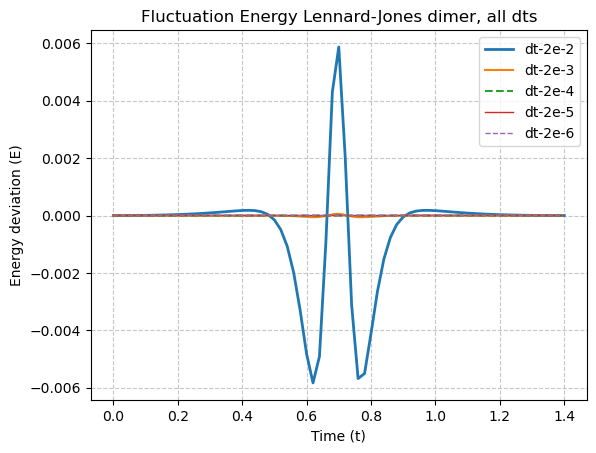

In [2]:

colors = plt.cm.tab10.colors

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(f'Fluctuation Energy Lennard-Jones dimer, all dts')
plt.plot(time_dE[0],dEs[0], linestyle = "-", linewidth=2, color=colors[0], label ="dt-2e-2")
plt.plot(time_dE[1],dEs[1], linestyle = "-", linewidth=1.5, color=colors[1], label ="dt-2e-3")
plt.plot(time_dE[2],dEs[2], linestyle = "--", linewidth=1.5, color=colors[2], label ="dt-2e-4")
plt.plot(time_dE[3],dEs[3], linestyle = "-", linewidth=1, color=colors[3], label ="dt-2e-5")
plt.plot(time_dE[4],dEs[4], linestyle = "--", linewidth=1, color=colors[4], label ="dt-2e-6")
plt.xlabel('Time (t)')
plt.ylabel('Energy deviation (E)')
plt.legend()
plt.savefig(f'ex_1_fluctuation_all_dt.png')
plt.show()


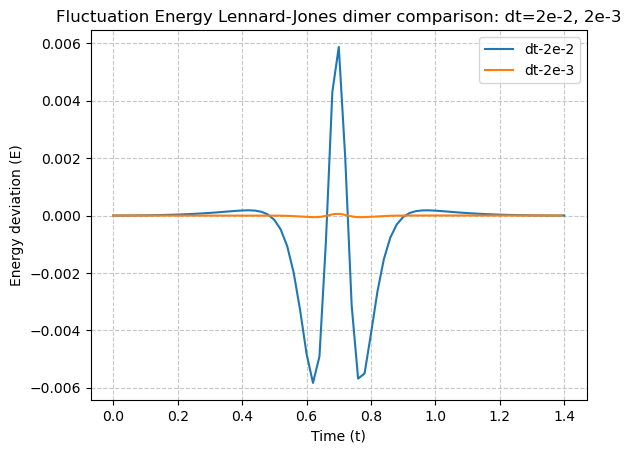

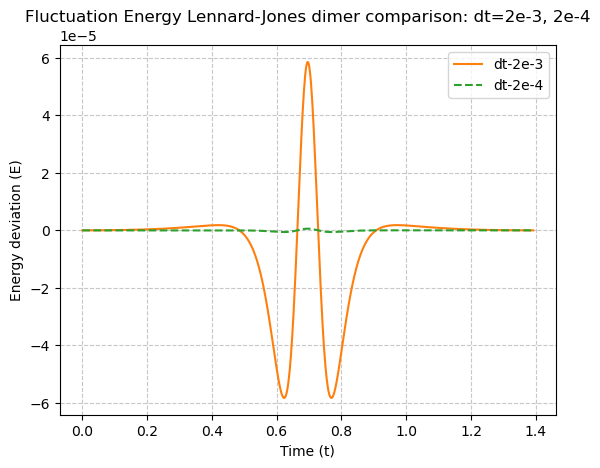

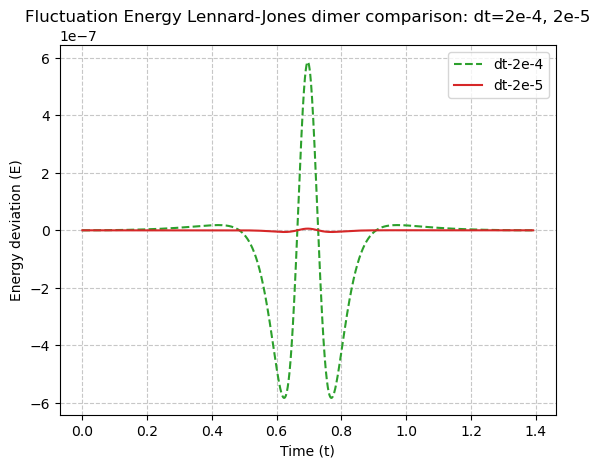

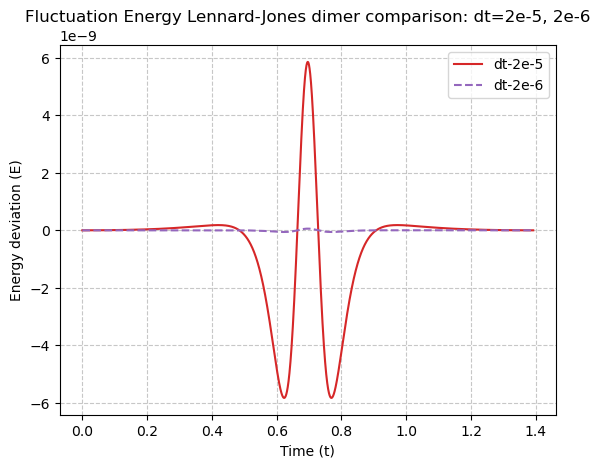

In [3]:

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(f'Fluctuation Energy Lennard-Jones dimer comparison: dt=2e-2, 2e-3')
plt.plot(time_dE[0],dEs[0], linestyle = "-", color=colors[0], label ="dt-2e-2")
plt.plot(time_dE[1],dEs[1], linestyle = "-", color=colors[1], label ="dt-2e-3")
plt.xlabel('Time (t)')
plt.ylabel('Energy deviation (E)')
plt.legend()
plt.savefig(f'ex_1_fluctuation_dt=2e-2, 2e-3.png')
plt.show()


plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(f'Fluctuation Energy Lennard-Jones dimer comparison: dt=2e-3, 2e-4')
plt.plot(time_dE[1],dEs[1], linestyle = "-", color=colors[1], label ="dt-2e-3")
plt.plot(time_dE[2],dEs[2], linestyle = "--", color=colors[2], label ="dt-2e-4")
plt.xlabel('Time (t)')
plt.ylabel('Energy deviation (E)')
plt.legend()
plt.savefig(f'ex_1_fluctuation_dt=2e-3, 2e-4.png')
plt.show()


plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(f'Fluctuation Energy Lennard-Jones dimer comparison: dt=2e-4, 2e-5')
plt.plot(time_dE[2],dEs[2], linestyle = "--", color=colors[2], label ="dt-2e-4")
plt.plot(time_dE[3],dEs[3], linestyle = "-", color=colors[3], label ="dt-2e-5")
plt.xlabel('Time (t)')
plt.ylabel('Energy deviation (E)')
plt.legend()
plt.savefig(f'ex_1_fluctuation_dt=2e-4, 2e-5.png')
plt.show()


plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(f'Fluctuation Energy Lennard-Jones dimer comparison: dt=2e-5, 2e-6')
plt.plot(time_dE[3],dEs[3], linestyle = "-", color=colors[3], label ="dt-2e-5")
plt.plot(time_dE[4],dEs[4], linestyle = "--", color=colors[4], label ="dt-2e-6")
plt.xlabel('Time (t)')
plt.ylabel('Energy deviation (E)')
plt.legend()
plt.savefig(f'ex_1_fluctuation_dt=2e-5, 2e-6.png')
plt.show()



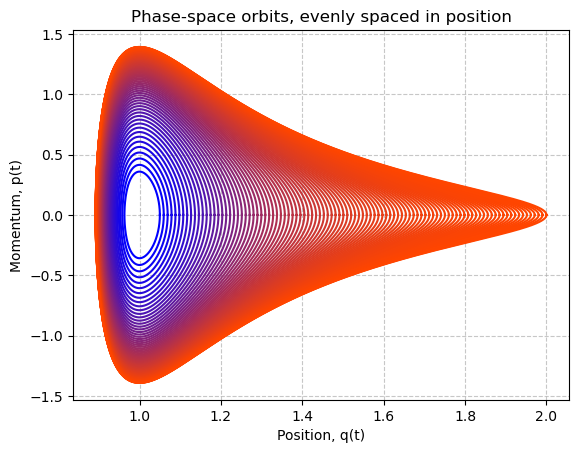

In [4]:
#ex 1.b

import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

def total_energy(p, x):
    Kin = 0.5*(p**2)
    Pot = normalized_lj_potential(x)
    T = np.add(Kin,Pot)
    return T


q0_values=np.linspace(1.05,2,100)
energies_even_pos=[]
trajectories_even_pos=[]

for q0 in q0_values:
    result=velocity_verlet_integrator(q0, normalized_lj_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    E=total_energy(p, x)[0]
    energies_even_pos.append(E)
    trajectories_even_pos.append((x,p))
    
energies_even_pos = np.array(energies_even_pos)
norm = (energies_even_pos - energies_even_pos.min()) / (energies_even_pos.max() - energies_even_pos.min())

colors =["blue", "orangered"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)

for i, (q, p) in enumerate(trajectories_even_pos):
    color = cmap(norm[i])
    plt.plot(q, p, color=color, linewidth=1.5)

plt.title('Phase-space orbits, evenly spaced in position')
plt.xlabel('Position, q(t)')
plt.ylabel('Momentum, p(t)')
plt.savefig("phase_orb_even_pos.png")
plt.show()

In [ ]:
from scipy.interpolate import CubicSpline

q0_test=np.linspace(1.05,2,1000)
energies_test=[]
trajectories_even_E=[]
#for 1.c
J = []
T = []

for q0 in q0_test:
    result=velocity_verlet_integrator(q0, normalized_lj_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    E_test=total_energy(p, x)[0]
    energies_test.append(E_test)
    
energies_test = np.array(energies_test)

energies_values=np.linspace(energies_test.min(), energies_test.max(), 100)

q0_values = np.interp(energies_values, energies_test, q0_test)

norm = (energies_values - energies_values.min()) / (energies_values.max() - energies_values.min())

for q0 in q0_values:
    result=velocity_verlet_integrator(q0, normalized_lj_force, 2e-4)
    if result==None:
        continue
    x,p,t = result
    trajectories_even_E.append((x,p))
    T.append(t[-1])
    
    A= 0.5 * np.abs(np.sum(x[:-1] * p[1:] - x[1:] * p[:-1]))
    J.append(A/(2*np.pi))

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.plot(energies_values, J)
plt.title('J(E), evenly spaced in total energy')
plt.xlabel('Energy, E')
plt.ylabel('J, J(E)')
plt.savefig('J_E.png')
plt.show()


plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)

for i, (q, p) in enumerate(trajectories_even_E):
    color = cmap(norm[i])
    plt.plot(q, p, color=color, linewidth=1.5)

plt.title('Phase-space orbits, evenly spaced in total energy')
plt.xlabel('Position, q(t)')
plt.ylabel('Momentum, p(t)')
plt.savefig("phase_orb_even_E.png")
plt.show()

In [ ]:
#ex 1.c.2

cs=CubicSpline(energies_values,J)
Omega=cs(energies_values,1)

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.plot(energies_values, Omega)
plt.title('multiplicity, evenly spaced in total energy')
plt.xlabel('Energy, E')
plt.ylabel(r'multiplicity $\Omega(E)$')
plt.savefig('multiplicity_evenly_spaced_energy.png')
plt.show()

S = np.log(Omega)

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.plot(energies_values, S)
plt.title('Entropy, evenly spaced in total energy')
plt.xlabel('Energy, E')
plt.ylabel('entropy, S(E)')
plt.savefig('entropy_evenly_spaced_energy.png')
plt.show()

plt.figure()
plt.grid(True,linestyle='--', alpha=0.7)
plt.plot(energies_values, 2*np.pi*Omega, label=r"2π$\Omega$(E)")
plt.plot(energies_values, T, 'r--', label = "T(E)")
plt.title('Period comparison, evenly spaced in total energy')
plt.xlabel('Energy, E')
plt.ylabel('Period, T(E)')
plt.legend()
plt.savefig('period_evenly_spaced_energy.png')
plt.show()





In [ ]:
#1.d
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.integrate import simpson


betas= np.linspace(0.1,10,200)
T = 1/betas

def partition_function(energies_values, Omega, beta):
    integrand = Omega * np.exp(-beta * energies_values)
    Z = simpson(y=integrand, x=energies_values)
    return Z

def internal_U(energies_values, Omega, betas):
    Z_vals = np.array([
        partition_function(energies_values, Omega, b)
        for b in betas
    ])
    cs_1 = CubicSpline(betas, np.log(Z_vals))
    U = -cs_1(betas, 1)
    return U

def heat_capacity(energies_values, Omega, betas):
    T = 1/betas
    U = internal_U(energies_values, Omega, betas)
    cs_b = CubicSpline(betas, U)
    C_1 = cs_b(betas, 1)
    cs_T = CubicSpline(betas, T)
    C_2 = cs_T(betas, 1)
    return C_1/C_2

def heat_capacity_new(energies_values, Omega, betas):
    T = 1/betas
    U = internal_U(energies_values, Omega, betas)
    cs_b = CubicSpline(betas, U)
    C_1 = cs_b(betas, 1)
    return -C_1*(betas)**2

plt.plot(T, [partition_function(energies_values, Omega, b) for b in betas], label='Partition function')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Partition function as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'Partition function, Z($\beta$)')
plt.savefig('partition_function.png')
plt.show()

plt.figure()
plt.plot(T, internal_U(energies_values, Omega, betas), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Internal energy, $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'Internal energy, U')
plt.savefig('Internal_energy.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_new(energies_values, Omega, betas), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'heat test, $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.show()


plt.figure()
plt.plot(T, heat_capacity(energies_values, Omega, betas), label='Heat Capacity')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title('Heat capacity as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel('Heat Capacity, C')
plt.savefig('heat_capacity_.png')
plt.show()

In [ ]:
def partition_free_energy(L, beta):
    Z_free = L/np.sqrt(2*np.pi*beta) 
    return Z_free

def partition_function_total(energies, Omega, betas, L):
    Z_bound = np.array([partition_function(energies, Omega, beta) for beta in betas])
    Z_free = np.array([partition_free_energy(L, beta) for beta in betas])
    Z_total = Z_bound + Z_free
    return Z_total

def internal_U_L(energies, Omega, betas, L):
    Z = partition_function_total(energies, Omega, betas, L) 
    cs_Z = CubicSpline(betas, np.log(Z))
    expected_E = - cs_Z(betas, 1)
    return expected_E

def heat_capacity_L(energies_values, Omega, betas, L):
    T = 1/betas
    U_L = internal_U_L(energies_values, Omega, betas, L)
    cs_b = CubicSpline(betas, U_L)
    C_1 = cs_b(betas, 1)
    cs_T = CubicSpline(betas, T)
    C_2 = cs_T(betas, 1)
    return C_1/C_2

def heat_capacity_L_new(energies_values, Omega, betas, L):
    T = 1/betas
    U_L = internal_U_L(energies_values, Omega, betas, L)
    cs_b = CubicSpline(betas, U_L)
    C_1 = cs_b(betas, 1)
    return -C_1*(betas)**2
    
plt.figure()
plt.plot(T, internal_U_L(energies_values, Omega, betas, L=10), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Internal energy as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'internal energy, $\langle E \rangle$')
plt.savefig('internal_energy_L=10.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_L(energies_values, Omega, betas, L=10), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Heat capacity as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.savefig('heat_capacity_L=10.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_L_new(energies_values, Omega, betas, L=10), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Heat capacity test as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.show()

In [ ]:
    
plt.figure()
plt.plot(T, internal_U_L(energies_values, Omega, betas, L=100), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Internal energy as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'internal energy, $\langle E \rangle$')
plt.savefig('internal_energy_L=100.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_L(energies_values, Omega, betas, L=100), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Heat capacity as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.savefig('heat_capacity_L=100.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_L_new(energies_values, Omega, betas, L=100), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Heat capacity test as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.show()

In [ ]:
    
plt.figure()
plt.plot(T, internal_U_L(energies_values, Omega, betas, L=1), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Internal energy as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'internal energy, $\langle E \rangle$')
plt.savefig('internal_energy_L=1.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_L(energies_values, Omega, betas, L=1), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Heat capacity as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.savefig('heat_capacity_L=1.png')
plt.show()

plt.figure()
plt.plot(T, heat_capacity_L_new(energies_values, Omega, betas, L=1), label='Expected Energy')
plt.grid(True,linestyle='--', alpha=0.7)
plt.title(r'Heat capacity test as a function of $k_BT$')
plt.xlabel(r'$k_BT$')
plt.ylabel(r'heat capacity, C')
plt.show()